In [3]:
%load_ext cython

In [7]:
# === PYTHON IMPORTS AND LLM INTERFACE ===

import numpy as np
import matplotlib.pyplot as plt
import time
import os
import json
import requests
from typing import Dict, List, Tuple

print("=== PYTHON IMPORTS AND LLM INTERFACE ===")

class SimplifiedLLMInterface:
    """
    Simplified LLM interface for Ollama Llama 3.
    Provides parameter tuning for multi-objective optimization.
    """
    def __init__(self, model_path="llama3:latest"):
        self.model_path = model_path
        self.connection_status = None
        self._verify_connection()
        self.cache = {}

    def _verify_connection(self):
        """Verify if LLaMA-3 is available via Ollama"""
        try:
            response = requests.get('http://localhost:11434/api/tags', timeout=5)
            if response.status_code == 200:
                models = response.json().get('models', [])
                model_names = [model['name'] for model in models]
                if self.model_path in model_names:
                    self.connection_status = "ollama_connected"
                    print(f"✅ Ollama connected with {self.model_path}")
                    return True
                else:
                    self.connection_status = "ollama_no_model"
            else:
                self.connection_status = "ollama_failed"
        except Exception:
            self.connection_status = "ollama_unavailable"
        return False

    def _call_ollama(self, prompt):
        """Call Ollama's API for LLaMA-3 with given prompt"""
        try:
            response = requests.post(
                'http://localhost:11434/api/generate',
                json={
                    'model': self.model_path,
                    'prompt': prompt,
                    'stream': False,
                    'options': {
                        'temperature': 0.7,
                        'num_predict': 200,
                        'timeout': 30
                    }
                },
                timeout=60
            )
            if response.status_code == 200:
                return response.json()['response']
            else:
                return None
        except Exception:
            return None

    def get_optimized_params(self, instance_features, target_performance):
        """
        Get optimized parameters for MO Knapsack from LLM or fallback.
        Returns: dict with keys alpha, kappa, L, operators
        """
        cache_key = f"{instance_features['signature']}_{instance_features['subclass']}"
        if cache_key in self.cache:
            print(f"✅ Using cached parameters for {cache_key}")
            return self.cache[cache_key]
        if self.connection_status != "ollama_connected":
            # Fallback to rule-based approach
            return self._get_rule_based_params(instance_features)

        prompt = f"""
Optimize parameters for multi-objective knapsack problem:

Instance Features:
- Items: {instance_features['n_items']}
- Objectives: {instance_features['n_objectives']}
- Size: {instance_features['instance_size']}
- Capacity: {instance_features.get('capacity_tightness', 'medium')}

Target Performance: {target_performance:,.0f}

Return JSON with optimized parameters:
{{
    "alpha": 40,
    "kappa": 0.15,
    "L": 6,
    "operators": ["swap", "greedy_add", "local_search"]
}}
"""
        response = self._call_ollama(prompt)
        if response:
            try:
                # Extract JSON from response
                start_idx = response.find('{')
                end_idx = response.rfind('}') + 1
                if start_idx != -1 and end_idx != 0:
                    json_str = response[start_idx:end_idx]
                    params = json.loads(json_str)
                    # Validate and adjust
                    params['alpha'] = min(60, max(20, int(params.get('alpha', 40))))
                    params['kappa'] = min(0.25, max(0.03, float(params.get('kappa', 0.15))))
                    params['L'] = min(12, max(2, int(params.get('L', 6))))
                    valid_operators = ['swap', 'greedy_add', 'local_search', 'mutation', 'repair']
                    operators = params.get('operators', ['swap', 'greedy_add', 'local_search'])
                    if isinstance(operators, str):
                        operators = [operators]
                    params['operators'] = [op for op in operators if op in valid_operators]
                    if not params['operators']:
                        params['operators'] = ['swap', 'greedy_add', 'local_search']
                    self.cache[cache_key] = params
                    print(f"✅ Got optimized parameters from LLM")
                    return params
            except json.JSONDecodeError:
                print(f"⚠️ Could not parse JSON from LLM response")
        # Fallback to rule-based
        params = self._get_rule_based_params(instance_features)
        self.cache[cache_key] = params
        return params

    def _get_rule_based_params(self, instance_features):
        size = instance_features['instance_size']
        objectives = instance_features['n_objectives']
        capacity = instance_features.get('capacity_tightness', 'medium')
        if size == 'small':
            alpha = 35
            kappa = 0.12
            L = 5
        elif size == 'medium':
            alpha = 40
            kappa = 0.15
            L = 6
        else:
            alpha = 45
            kappa = 0.18
            L = 7
        if capacity == 'very_tight':
            alpha += 5
            L += 1
        elif capacity == 'loose':
            alpha -= 5
            L -= 1
        if capacity == 'very_tight':
            operators = ['swap', 'greedy_add', 'repair']
        elif objectives > 2:
            operators = ['swap', 'greedy_add', 'local_search', 'mutation']
        else:
            operators = ['swap', 'greedy_add', 'local_search']
        return {
            'alpha': alpha,
            'kappa': kappa,
            'L': L,
            'operators': operators
        }

print("✅ Python imports and LLM interface ready!")

=== PYTHON IMPORTS AND LLM INTERFACE ===
✅ Python imports and LLM interface ready!


In [8]:
llm = SimplifiedLLMInterface(model_path="llama3:latest")

✅ Ollama connected with llama3:latest


In [9]:
%%cython

# NOTE: This cell must be run with Cython support (e.g., in a Jupyter notebook, use %%cython at the top)
# You may need to install Cython and restart your kernel.

import numpy as np
from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp
import time

# ========== Cython MOACP Implementation ==========

cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Globals
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

cdef void loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

cdef void read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_bound

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# Simplified operators
cdef ind *apply_swap(ind *x):
    idx1 = irand(ni)
    idx2 = irand(ni)
    while idx2 == idx1:
        idx2 = irand(ni)
    tmp = x.d[idx1]
    x.d[idx1] = x.d[idx2]
    x.d[idx2] = tmp
    return x

cdef ind *apply_greedy_add(ind *x, pop *SP):
    cdef int i, j, best_idx
    cdef double best_ratio, current_ratio, total_profit, total_weight
    cdef bint feasible
    best_idx = -1
    best_ratio = -1.0
    for i in range(ni):
        if x.Items[i] == 0:
            feasible = 1
            for j in range(nf):
                if x.capa[j] + weights[j][i] > capacities[j]:
                    feasible = 0
                    break
            if feasible:
                total_profit = 0.0
                total_weight = 0.0
                for j in range(nf):
                    total_profit += profits[j][i]
                    total_weight += weights[j][i]
                current_ratio = total_profit / total_weight if total_weight > 0 else 0.0
                if current_ratio > best_ratio:
                    best_ratio = current_ratio
                    best_idx = i
    if best_idx != -1:
        x.Items[best_idx] = 1
        x.nombr += 1
        x.nombr_nonpris -= 1
        for j in range(nf):
            x.capa[j] += weights[j][best_idx]
            x.f[j] += profits[j][best_idx]
    return x

cdef ind *apply_local_search(ind *x, pop *SP):
    cdef int i, j, k, best_neighbor
    cdef double best_improvement, current_improvement
    best_neighbor = -1
    best_improvement = 0.0
    for i in range(ni):
        if x.Items[i] == 1:
            x.Items[i] = 0
            x.nombr -= 1
            x.nombr_nonpris += 1
            for j in range(nf):
                x.capa[j] -= weights[j][i]
                x.f[j] -= profits[j][i]
            for k in range(ni):
                if k != i and x.Items[k] == 0:
                    feasible = 1
                    for j in range(nf):
                        if x.capa[j] + weights[j][k] > capacities[j]:
                            feasible = 0
                            break
                    if feasible:
                        current_improvement = 0.0
                        for j in range(nf):
                            current_improvement += profits[j][k] - profits[j][i]
                        if current_improvement > best_improvement:
                            best_improvement = current_improvement
                            best_neighbor = k
            if best_neighbor == -1:
                x.Items[i] = 1
                x.nombr += 1
                x.nombr_nonpris -= 1
                for j in range(nf):
                    x.capa[j] += weights[j][i]
                    x.f[j] += profits[j][i]
            else:
                x.Items[best_neighbor] = 1
                x.nombr += 1
                x.nombr_nonpris -= 1
                for j in range(nf):
                    x.capa[j] += weights[j][best_neighbor]
                    x.f[j] += profits[j][best_neighbor]
                break
    return x

cdef ind *apply_mutation(ind *x):
    cdef int num_mutations, i, mutation_idx, new_pos
    num_mutations = max(1, ni // 10)
    for i in range(num_mutations):
        mutation_idx = irand(ni)
        new_pos = irand(ni)
        x.d[mutation_idx] = new_pos
    return x

cdef ind *apply_repair(ind *x):
    cdef int i, j, worst_idx
    cdef bint is_feasible
    cdef double worst_ratio, current_ratio
    is_feasible = 1
    for j in range(nf):
        if x.capa[j] > capacities[j]:
            is_feasible = 0
            break
    if is_feasible:
        return x
    while not is_feasible:
        is_feasible = 1
        worst_idx = -1
        worst_ratio = 1e10
        for i in range(ni):
            if x.Items[i] == 1:
                current_ratio = 0.0
                for j in range(nf):
                    if weights[j][i] > 0:
                        current_ratio += profits[j][i] / weights[j][i]
                if current_ratio < worst_ratio:
                    worst_ratio = current_ratio
                    worst_idx = i
        if worst_idx != -1:
            x.Items[worst_idx] = 0
            x.nombr -= 1
            x.nombr_nonpris += 1
            for j in range(nf):
                x.capa[j] -= weights[j][worst_idx]
                x.f[j] -= profits[j][worst_idx]
        for j in range(nf):
            if x.capa[j] > capacities[j]:
                is_feasible = 0
                break
    return x

# Simplified operator with runtime control
cdef void simplified_llm_inspired_operator(pop *SP, pop *Sarchive, int size, double time_budget, list operators):
    cdef bint use_swap = 'swap' in operators
    cdef bint use_greedy_add = 'greedy_add' in operators
    cdef bint use_mutation = 'mutation' in operators
    cdef bint use_local_search = 'local_search' in operators
    cdef bint use_repair = 'repair' in operators
    cdef ind *x, *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    cdef double start_time = time.time()
    cdef double current_time
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    cdef int max_iterations = 50
    cdef int iteration_count = 0
    while (time.time() - start_time) < time_budget * 0.9 and iteration_count < max_iterations:
        convergence = 0
        for i in range(SP.size):
            current_time = time.time()
            if (current_time - start_time) > time_budget * 0.9:
                break
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr and (current_time - start_time) < time_budget * 0.9:
                    for l in range(L):
                        remplace[l] = 0
                    if use_swap and irand(100) < 70:
                        x = apply_swap(x)
                    elif use_mutation and irand(100) < 60:
                        x = apply_mutation(x)
                    elif use_greedy_add and irand(100) < 80:
                        x = apply_greedy_add(x, SP)
                    else:
                        x = apply_local_search(x, SP)
                    if use_repair:
                        x = apply_repair(x)
                    mino = irand(ni)
                    while x.Items[mino] != 1 and j < x.nombr:
                        mino = irand(ni)
                    if x.Items[mino] == 1:
                        x.Items[mino] = 0
                        x.nombr -= 1
                        x.nombr_nonpris += 1
                        for r in range(nf):
                            x.capa[r] -= weights[r][mino]
                            x.f[r] -= profits[r][mino]
                        IM = 0
                        taille = 0
                        while IM < L and (current_time - start_time) < time_budget * 0.9:
                            while True:
                                maxp = irand(ni)
                                if x.Items[maxp] == 0:
                                    break
                            if maxp != mino:
                                consistant = 1
                                r = 0
                                while r < nf and consistant == 1:
                                    if x.capa[r] + weights[r][maxp] > capacities[r]:
                                        consistant = 0
                                    r += 1
                                if consistant == 1:
                                    feasible = 1
                                    r = 0
                                    while r < taille and feasible:
                                        if maxp == remplace[r]:
                                            feasible = 0
                                        r += 1
                                    if feasible == 1:
                                        remplace[taille] = maxp
                                        taille += 1
                                        x.Items[maxp] = 1
                                        x.nombr_nonpris -= 1
                                        x.nombr += 1
                                        for r in range(nf):
                                            x.capa[r] += weights[r][maxp]
                                            x.f[r] += profits[r][maxp]
                            IM += 1
                        for tv in range(nf):
                            x.v[tv] = x.f[tv] * vector_weight[tv]
                        max_bound = calcMaxbound(SP, SP.size)
                        sol = compute_fitness_and_select(SP, x, SP.size)
                        if sol != -1:
                            j = x.nombr + 1
                            if sol > i and i + 1 < SP.size:
                                y = SP.ind_array[i + 1]
                                SP.ind_array[i + 1] = SP.ind_array[sol]
                                SP.ind_array[sol] = y
                                i += 1
                            break
                        elif sol == -1:
                            x.Items[mino] = 1
                            x.nombr_nonpris -= 1
                            x.nombr += 1
                            for r in range(nf):
                                x.capa[r] += weights[r][mino]
                                x.f[r] += profits[r][mino]
                            if taille >= 1:
                                for r in range(taille):
                                    x.Items[remplace[r]] = 0
                                    x.nombr -= 1
                                    x.nombr_nonpris += 1
                                    for t in range(nf):
                                        x.capa[t] -= weights[t][remplace[r]]
                                        x.f[t] -= profits[t][remplace[r]]
                                        x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
        iteration_count += 1
    free(remplace)

cdef void set_simplified_parameters(object custom_params=None, list operators=None, bint print_params=True):
    global alpha, kappa, L, smallValue
    if custom_params is not None:
        new_alpha = int(custom_params.get('alpha', 40))
        new_kappa = float(custom_params.get('kappa', 0.15))
        new_L = int(custom_params.get('L', 6))
        new_small_value = float(custom_params.get('small_value', 1e-7))
        alpha = min(60, max(20, new_alpha))
        kappa = min(0.25, max(0.03, new_kappa))
        L = min(12, max(2, new_L))
        smallValue = min(1e-6, max(1e-9, new_small_value))
        if print_params:
            print(f"🚀 Simplified Parameters: alpha={alpha}, kappa={kappa:.3f}, L={L}, small={smallValue:.1e}")
    else:
        alpha = 40
        kappa = 0.15
        L = 6
        smallValue = 1e-7
        if print_params:
            print(f"📊 Default Parameters: alpha={alpha}, kappa={kappa:.3f}, L={L}, small={smallValue:.1e}")
    if operators is not None:
        print(f"   Operators: {operators}")

def run_simplified_llm_inspired_moacp(
    instance_file,
    weights_file,
    nbitems,
    num_objectives,
    custom_params=None,
    operators=None,
    print_params=True,
    runtime_threshold=20.0,
    num_runs=5,
    num_iterations=50
):
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights
    set_simplified_parameters(custom_params, operators, print_params)
    NBITEMS = nbitems
    ni = nbitems
    nf = num_objectives
    paretoIni = 28000
    all_pareto_solutions = []
    run_times = []
    if print_params:
        print(f"\n Simplified LLM-Inspired MOACP: {num_runs} runs × {num_iterations} iterations")
        print(f" Runtime threshold: {runtime_threshold:.2f}s per run")
    total_start_time = time.time()
    for run in range(1, num_runs + 1):
        run_start_time = time.time()
        if print_params:
            print(f"   Run {run}/{num_runs}...", end=" ")
        nombreLIGNE = 0
        nextLn = 0
        inv = 0
        seed(run)
        loadMOKP(instance_file.encode())
        read_weights_file(weights_file.encode())
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)
        it = 0
        while it < num_iterations:
            iteration_start = time.time()
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            simplified_llm_inspired_operator(solutions, archive, alpha, runtime_threshold * 0.8, operators)
            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)
        run_pareto = []
        for i in range(P.size):
            if P.ind_array[i] != NULL:
                obj1 = P.ind_array[i].f[0]
                obj2 = P.ind_array[i].f[1] if nf > 1 else 0
                run_pareto.append([obj1, obj2])
        all_pareto_solutions.extend(run_pareto)
        pareto_np = np.array(run_pareto)
        if pareto_np.shape[0] > 0:
            max_obj1 = np.max(pareto_np[:, 0])
            min_obj1 = np.min(pareto_np[:, 0])
            spread_obj1 = max_obj1 - min_obj1
            max_obj2 = np.max(pareto_np[:, 1])
            min_obj2 = np.min(pareto_np[:, 1])
            spread_obj2 = max_obj2 - min_obj2
        else:
            max_obj1 = min_obj1 = spread_obj1 = 0
            max_obj2 = min_obj2 = spread_obj2 = 0
        run_time = time.time() - run_start_time
        run_times.append(run_time)
        if print_params:
            status = "⚠️" if run_time > runtime_threshold else "✓"
            print(f"{status} {len(run_pareto)} solutions, {run_time:.2f}s")
        complete_free_pop(P)
        cleanup_globals()
    total_time = time.time() - total_start_time
    avg_time_per_run = total_time / num_runs if num_runs > 0 else 0.0
    if print_params:
        print(f" Simplified Complete: {len(all_pareto_solutions)} total solutions, {total_time:.2f}s total, {avg_time_per_run:.2f}s avg/run")
    return {
        'pareto_solutions': np.array(all_pareto_solutions) if all_pareto_solutions else np.array([]),
        'total_time': total_time,
        'avg_time_per_run': avg_time_per_run,
        'run_times': run_times,
        'parameters': {
            'alpha': alpha,
            'kappa': kappa,
            'L': L,
            'small_value': smallValue
        },
        'num_solutions': len(all_pareto_solutions),
        'num_runs': num_runs,
        'num_iterations': num_iterations,
        'operators': operators,
        'max_obj1': max_obj1,
        'min_obj1': min_obj1,
        'spread_obj1': spread_obj1,
        'max_obj2': max_obj2,
        'min_obj2': min_obj2,
        'spread_obj2':  spread_obj2
    }

print("✅ Cython implementation ready!")

Content of stdout:
_cython_magic_d59c77d41771f674dfb4a31b2be2f62af1d4412733b74b920dbe1adb8983c4f5.c
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_d59c77d41771f674dfb4a31b2be2f62af1d4412733b74b920dbe1adb8983c4f5.c(4870): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_d59c77d41771f674dfb4a31b2be2f62af1d4412733b74b920dbe1adb8983c4f5.c(4960): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_d59c77d41771f674dfb4a31b2be2f62af1d4412733b74b920dbe1adb8983c4f5.c(5970): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_d59c77d41771f674dfb4a31b2be2f62af1d4412733b74b920dbe1adb8983c4f5.c(11121): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_d59c77d4

In [10]:
# === Utility functions for MO Knapsack Pareto analysis and visualization ===

import numpy as np
import matplotlib.pyplot as plt
import os

def calculate_hypervolume_2d(pareto_points, reference_point=None):
    """
    Calculate hypervolume for 2D Pareto front (maximization).
    Assumes Pareto points are non-dominated and sorted.
    """
    if len(pareto_points) == 0:
        return 0.0

    # Sort points by first objective (ascending for maximization)
    sorted_points = pareto_points[np.argsort(pareto_points[:, 0])]

    # Set reference point if not provided
    if reference_point is None:
        reference_point = np.zeros(2)

    hypervolume = 0.0
    prev_x = reference_point[0]
    for point in sorted_points:
        width = point[0] - prev_x
        height = point[1] - reference_point[1]
        if width > 0 and height > 0:
            hypervolume += width * height
        prev_x = point[0]
    return hypervolume

def extract_instance_features(instance_file, weights_file, nbitems, num_objectives):
    """
    Extract features from the instance file for LLM parameter tuning.
    Returns a dict with feature keys.
    """
    features = {
        'n_items': nbitems,
        'n_objectives': num_objectives,
        'instance_size': 'small' if nbitems <= 250 else 'medium' if nbitems <= 500 else 'large',
        'signature': f"{nbitems}_{num_objectives}"
    }
    try:
        with open(instance_file, 'r') as f:
            lines = f.readlines()
            # Detect format: space-separated or colon-separated
            if len(lines) > 0:
                first_line = lines[0].strip()
                if ':' in first_line:
                    parts = first_line.split(':')
                    if len(parts) >= 2:
                        nums = parts[1].strip().split()
                        if len(nums) >= 2:
                            features['n_objectives'] = int(nums[0])
                            features['n_items'] = int(nums[1])
                else:
                    parts = first_line.split()
                    if len(parts) >= 2:
                        features['n_objectives'] = int(parts[0])
                        features['n_items'] = int(parts[1])
        # Capacity features
        capacities = []
        capacity_line_idx = 1
        for i in range(capacity_line_idx, min(capacity_line_idx + features['n_objectives'], len(lines))):
            if lines[i].strip():
                try:
                    capacities.append(float(lines[i].strip()))
                except ValueError:
                    continue
        if capacities:
            features['capacity_mean'] = np.mean(capacities)
            features['capacity_ratio'] = features['capacity_mean'] / nbitems
            if features['capacity_ratio'] > 0.8:
                features['capacity_tightness'] = 'very_tight'
            elif features['capacity_ratio'] > 0.6:
                features['capacity_tightness'] = 'tight'
            elif features['capacity_ratio'] > 0.4:
                features['capacity_tightness'] = 'medium'
            else:
                features['capacity_tightness'] = 'loose'
        else:
            features['capacity_tightness'] = 'medium'
        features['subclass'] = f"{features['capacity_tightness']}_capacity_{features['n_objectives']}obj"
    except Exception as e:
        print(f"Error extracting features: {e}")
        features['capacity_tightness'] = 'medium'
        features['subclass'] = f"medium_capacity_{features['n_objectives']}obj"
    return features

def calculate_reference_hv_for_instance(result_file):
    """
    Calculate reference hypervolume and Pareto front for a results file.
    Returns dict with Pareto points and hypervolume.
    """
    try:
        data = np.loadtxt(result_file)
        if data.ndim == 1:
            data = data.reshape(1, -1)
        data_unique = np.unique(data, axis=0)
        def is_pareto_efficient(points):
            is_efficient = np.ones(points.shape[0], dtype=bool)
            for i, c in enumerate(points):
                if is_efficient[i]:
                    is_efficient[is_efficient] = np.any(points[is_efficient] >= c, axis=1)
                    is_efficient[i] = True
            return is_efficient
        pareto_mask = is_pareto_efficient(data_unique)
        pareto_points = data_unique[pareto_mask]
        hv = calculate_hypervolume_2d(pareto_points)
        return {
            'all_solutions': data,
            'unique_solutions': data_unique,
            'pareto_solutions': pareto_points,
            'num_pareto': len(pareto_points),
            'hypervolume': hv
        }
    except Exception as e:
        print(f"Error loading result file {result_file}: {e}")
        return None

def visualize_pareto_comparison(reference_file, optimized_file, title="Pareto Front Comparison"):
    """
    Visualize and compare two Pareto fronts (reference and optimized).
    Saves plot as PNG.
    """
    ref_data = calculate_reference_hv_for_instance(reference_file)
    if not ref_data:
        print(f"Error loading reference file {reference_file}")
        return
    opt_data = calculate_reference_hv_for_instance(optimized_file)
    if not opt_data:
        print(f"Error loading optimized file {optimized_file}")
        return
    plt.figure(figsize=(12, 8))
    ref_pareto = ref_data['pareto_solutions']
    plt.scatter(ref_pareto[:, 0], ref_pareto[:, 1], 
                c='blue', alpha=0.7, label=f'Reference (HV: {ref_data["hypervolume"]:,.0f})')
    opt_pareto = opt_data['pareto_solutions']
    plt.scatter(opt_pareto[:, 0], opt_pareto[:, 1], 
                c='red', alpha=0.7, label=f'Optimized (HV: {opt_data["hypervolume"]:,.0f})')
    improvement = ((opt_data['hypervolume'] - ref_data['hypervolume']) / ref_data['hypervolume']) * 100
    plt.title(f"{title}\nImprovement: {improvement:.2f}%")
    plt.xlabel('Objective 1')
    plt.ylabel('Objective 2')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    filename = f"simplified_pareto_comparison_{os.path.basename(reference_file).replace('.txt', '')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Comparison plot saved: {filename}")
    plt.show()
    return improvement

print("✅ Utility functions ready!")

✅ Utility functions ready!


✅ Ollama connected with llama3:latest
✅ Simplified LLaMA-3 interface working!
Calculating reference hypervolumes for all instances...
Processing 2502_Resulats.txt...
✓ 250_2: HV = 97,640,877, Pareto points = 236
Processing 5002_Resulats.txt...
✓ 500_2: HV = 405,521,824, Pareto points = 396
Processing 7502_Resulats.txt...
✓ 750_2: HV = 898,857,593, Pareto points = 412

Reference hypervolumes calculated successfully!

SIMPLIFIED LLM-INSPIRED OPTIMIZATION: ./multiobjectives/250.2.txt
Instance signature: 250_2
Instance size: small
Subclass: very_tight_capacity_2obj
Reference HV: 97,640,877
Target HV: 102,522,921
LLM optimization time: 62.16s
Optimized parameters: α=40, κ=0.120, L=6
Operators: ['swap', 'greedy_add', 'repair']
🚀 Simplified Parameters: alpha=40, kappa=0.120, L=6, small=1.0e-07
   Operators: ['swap', 'greedy_add', 'repair']

 Simplified LLM-Inspired MOACP: 5 runs × 50 iterations
 Runtime threshold: 20.00s per run
✓ 127 solutions, 5.69s
✓ 136 solutions, 4.65s
   Run 3/5... ✓ 14

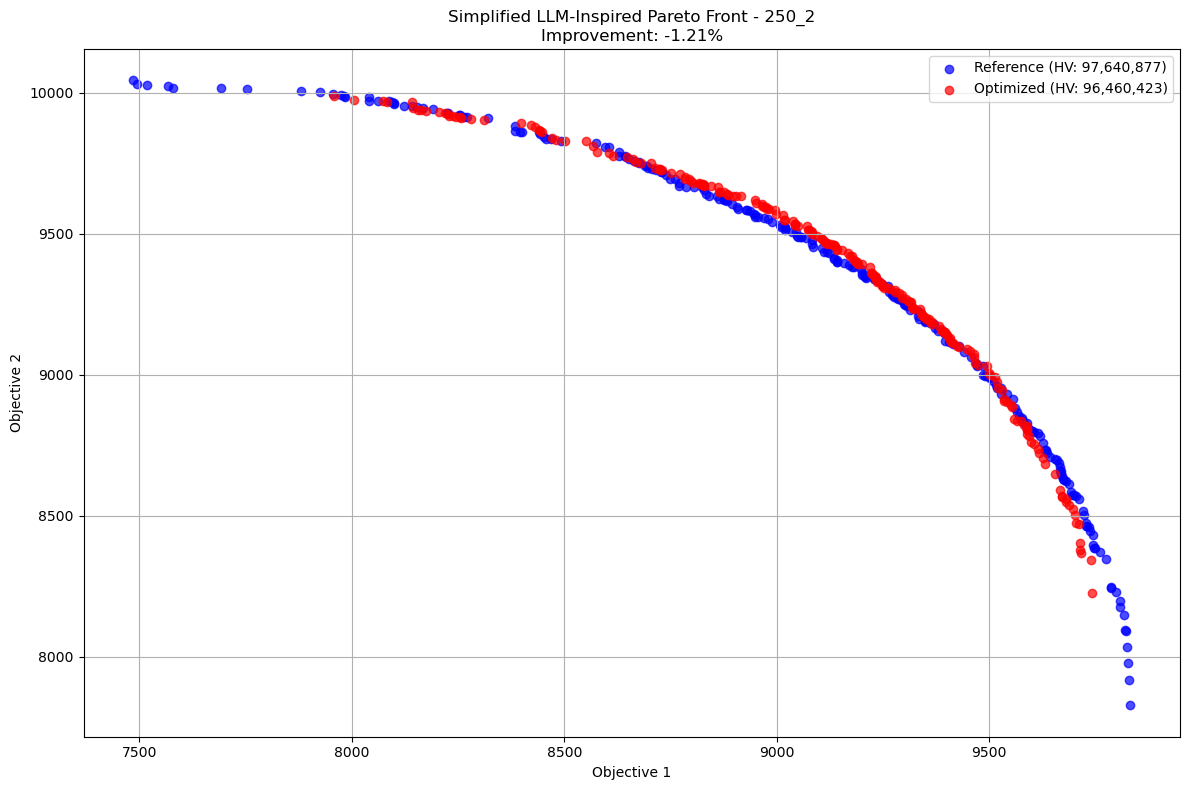


🏆 SIMPLIFIED OPTIMIZATION COMPLETE
Final HV: 96,392,977
Reference HV: 97,640,877
Improvement: -1.28%
Total time: 26.11s (including 62.16s for LLM)

SIMPLIFIED LLM-INSPIRED OPTIMIZATION: ./multiobjectives/500.2.txt
Instance signature: 500_2
Instance size: medium
Subclass: very_tight_capacity_2obj
Reference HV: 405,521,824
Target HV: 425,797,915
LLM optimization time: 47.87s
Optimized parameters: α=45, κ=0.150, L=7
Operators: ['swap', 'greedy_add', 'repair']
🚀 Simplified Parameters: alpha=45, kappa=0.150, L=7, small=1.0e-07
   Operators: ['swap', 'greedy_add', 'repair']

 Simplified LLM-Inspired MOACP: 5 runs × 50 iterations
 Runtime threshold: 20.00s per run
⚠️ 236 solutions, 48.62s
⚠️ 202 solutions, 43.63s
⚠️ 218 solutions, 42.34s
⚠️ 188 solutions, 45.34s
⚠️ 196 solutions, 49.92s
 Simplified Complete: 1040 total solutions, 229.85s total, 45.97s avg/run
Results saved to simplified_llm_optimized_500_2.txt
✅ Comparison plot saved: simplified_pareto_comparison_5002_Resulats.png


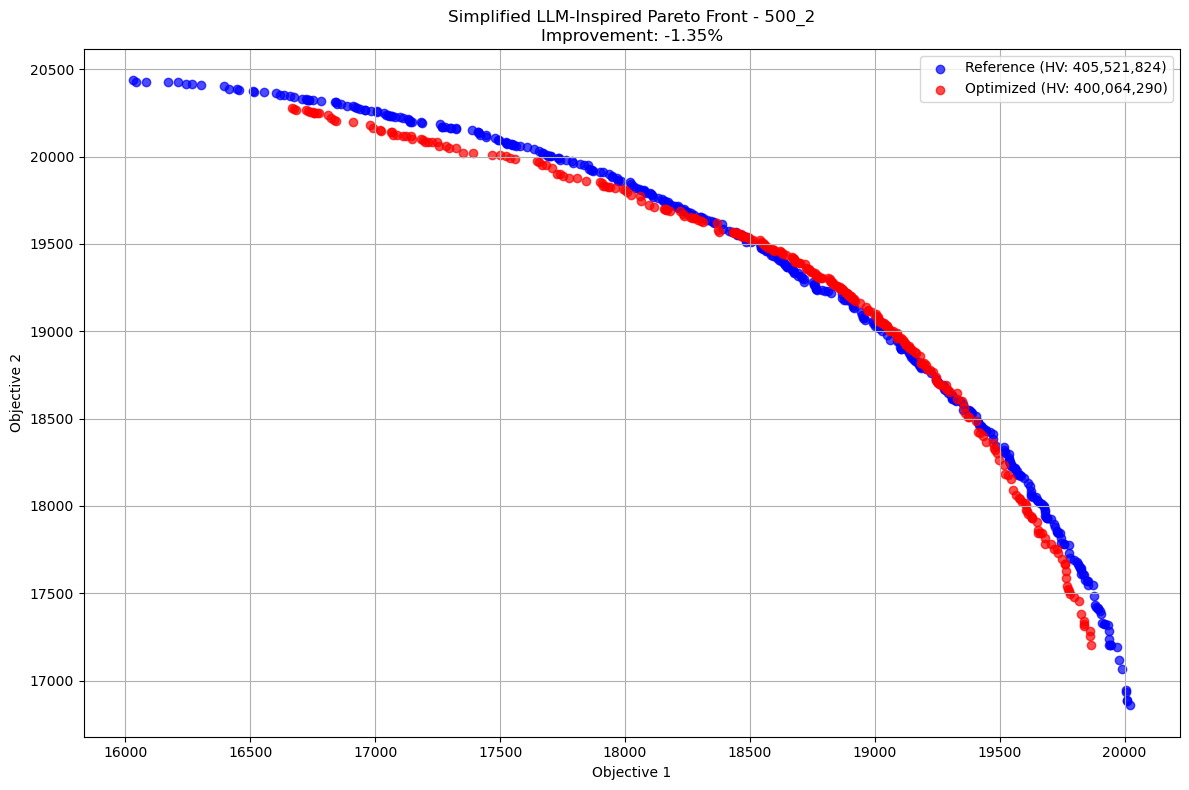


🏆 SIMPLIFIED OPTIMIZATION COMPLETE
Final HV: 399,955,701
Reference HV: 405,521,824
Improvement: -1.37%
Total time: 229.85s (including 47.87s for LLM)

SIMPLIFIED LLM-INSPIRED OPTIMIZATION: ./multiobjectives/750.2.txt
Instance signature: 750_2
Instance size: large
Subclass: very_tight_capacity_2obj
Reference HV: 898,857,593
Target HV: 943,800,473
LLM optimization time: 48.86s
Optimized parameters: α=50, κ=0.180, L=8
Operators: ['swap', 'greedy_add', 'repair']
🚀 Simplified Parameters: alpha=50, kappa=0.180, L=8, small=1.0e-07
   Operators: ['swap', 'greedy_add', 'repair']

 Simplified LLM-Inspired MOACP: 5 runs × 50 iterations
 Runtime threshold: 20.00s per run
   Run 1/5... 

KeyboardInterrupt: 

In [11]:
# === Main execution: LLM-driven MO Knapsack optimization experiment ===

import os
import time
import numpy as np

# Ensure previous cells are run: SimplifiedLLMInterface, run_simplified_llm_inspired_moacp, utility functions

if __name__ == "__main__":
    # 1. Initialize LLM interface
    try:
        simplified_llm = SimplifiedLLMInterface(model_path="llama3:latest")
        if simplified_llm.connection_status == "ollama_connected":
            print("✅ Simplified LLaMA-3 interface working!")
            llm_working = True
        else:
            print("⚠️ Simplified LLaMA-3 interface not working, using fallback")
            llm_working = False
    except Exception as e:
        print(f"❌ Failed to initialize Simplified LLaMA-3: {e}")
        llm_working = False
        simplified_llm = None

    # 2. Calculate reference hypervolumes for all instances
    reference_hvs = {}
    instance_files = [
        ("250_2", "2502_Resulats.txt"),
        ("500_2", "5002_Resulats.txt"),
        ("750_2", "7502_Resulats.txt")
    ]
    print("Calculating reference hypervolumes for all instances...")
    for instance_sig, result_file in instance_files:
        print(f"Processing {result_file}...")
        ref_data = calculate_reference_hv_for_instance(result_file)
        if ref_data:
            reference_hvs[instance_sig] = ref_data
            print(f"✓ {instance_sig}: HV = {ref_data['hypervolume']:,.0f}, Pareto points = {ref_data['num_pareto']}")
        else:
            print(f"❌ Failed to process {result_file}")
    print("\nReference hypervolumes calculated successfully!")

    # 3. Optimize all instances using the simplified approach
    instances_to_optimize = [
        ("./multiobjectives/250.2.txt", "./multiobjectives/Weights_2obj_FQ200.txt", 250, 2),
        ("./multiobjectives/500.2.txt", "./multiobjectives/Weights_2obj_FQ200.txt", 500, 2),
        ("./multiobjectives/750.2.txt", "./multiobjectives/Weights_2obj_FQ200.txt", 750, 2)
    ]
    results_summary = {}

    for instance_file, weights_file, nbitems, num_objectives in instances_to_optimize:
        print(f"\n{'='*60}")
        print(f"SIMPLIFIED LLM-INSPIRED OPTIMIZATION: {instance_file}")
        print(f"{'='*60}")
        if not os.path.exists(instance_file):
            print(f"❌ Instance file not found: {instance_file}")
            continue
        if not os.path.exists(weights_file):
            print(f"❌ Weights file not found: {weights_file}")
            continue

        instance_features = extract_instance_features(instance_file, weights_file, nbitems, num_objectives)
        instance_sig = f"{nbitems}_{num_objectives}"
        if instance_sig not in reference_hvs:
            print(f"❌ No reference data found for instance {instance_sig}")
            continue
        reference_data = reference_hvs[instance_sig]
        reference_hv = reference_data['hypervolume']
        target_hv = reference_hv * 1.05  # Aim for 5% improvement

        print(f"Instance signature: {instance_features['signature']}")
        print(f"Instance size: {instance_features['instance_size']}")
        print(f"Subclass: {instance_features['subclass']}")
        print(f"Reference HV: {reference_hv:,.0f}")
        print(f"Target HV: {target_hv:,.0f}")

        # Get optimized parameters from LLM (or fallback)
        start_time = time.time()
        optimized_params = simplified_llm.get_optimized_params(instance_features, target_hv)
        llm_time = time.time() - start_time
        print(f"LLM optimization time: {llm_time:.2f}s")
        print(f"Optimized parameters: α={optimized_params['alpha']}, κ={optimized_params['kappa']:.3f}, L={optimized_params['L']}")
        print(f"Operators: {optimized_params['operators']}")

        # Run optimization with optimized parameters
        result = run_simplified_llm_inspired_moacp(
            instance_file=instance_file,
            weights_file=weights_file,
            nbitems=nbitems,
            num_objectives=num_objectives,
            custom_params=optimized_params,
            operators=optimized_params['operators'],
            print_params=True,
            runtime_threshold=20.0,
            num_runs=5,
            num_iterations=50
        )

        # Calculate final hypervolume and improvement
        final_hv = calculate_hypervolume_2d(result['pareto_solutions'])
        improvement = ((final_hv - reference_hv) / reference_hv) * 100

        # Store results
        results_summary[instance_sig] = {
            'result': result,
            'params': optimized_params,
            'hv': final_hv,
            'reference_hv': reference_hv,
            'improvement': improvement,
            'llm_time': llm_time,
            'total_time': result['total_time']
        }

        # Save results
        output_file = f"simplified_llm_optimized_{instance_sig}.txt"
        np.savetxt(output_file, result['pareto_solutions'])
        print(f"Results saved to {output_file}")

        # Visualize comparison
        reference_file = f"{instance_sig.replace('_', '')}_Resulats.txt"
        if os.path.exists(reference_file):
            visualize_pareto_comparison(reference_file, output_file, f"Simplified LLM-Inspired Pareto Front - {instance_sig}")

        print(f"\n🏆 SIMPLIFIED OPTIMIZATION COMPLETE")
        print(f"Final HV: {final_hv:,.0f}")
        print(f"Reference HV: {reference_hv:,.0f}")
        print(f"Improvement: {improvement:.2f}%")
        print(f"Total time: {result['total_time']:.2f}s (including {llm_time:.2f}s for LLM)")

    # Overall summary
    print(f"\n{'='*60}")
    print("OVERALL SIMPLIFIED OPTIMIZATION SUMMARY")
    print(f"{'='*60}")

    for instance_sig, results in results_summary.items():
        print(f"\n{instance_sig}:")
        print(f"  Final HV: {results['hv']:,.0f}")
        print(f"  Reference HV: {results['reference_hv']:,.0f}")
        print(f"  Improvement: {results['improvement']:.2f}%")
        print(f"  Total time: {results['total_time']:.2f}s (LLM: {results['llm_time']:.2f}s)")
        print(f"  Best Config: α={results['params']['alpha']}, κ={results['params']['kappa']:.3f}, L={results['params']['L']}")
        print(f"  Operators: {results['params']['operators']}")

    # Calculate and print average statistics
    if results_summary:
        avg_improvement = np.mean([results['improvement'] for results in results_summary.values()])
        avg_total_time = np.mean([results['total_time'] for results in results_summary.values()])
        avg_llm_time = np.mean([results['llm_time'] for results in results_summary.values()])
        print(f"\n📊 AVERAGE RESULTS:")
        print(f"  Average improvement: {avg_improvement:.2f}%")
        print(f"  Average total time: {avg_total_time:.2f}s")
        print(f"  Average LLM time: {avg_llm_time:.2f}s")
        print(f"  Average optimization time: {avg_total_time - avg_llm_time:.2f}s")